<a href="https://colab.research.google.com/github/Fauzi455/PembelajaranMesin_2026/blob/main/JS-06/LAB-2/Klasifikasi%20SVM%20dengan%20Data%20Dummy%20Non-Linier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab 2

Langkah 1 - Ilustrasi Data Non-Linier

Langkah 1a - Import Library

In [38]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

Langkah 1b - Buat Kembali Fungsi Plotting

In [39]:
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

	    if ax is None:
	        ax = plt.gca()
	    xlim = ax.get_xlim()
	    ylim = ax.get_ylim()

	    # buat grid untuk evaluasi model
	    x = np.linspace(xlim[0], xlim[1], 30)
	    y = np.linspace(ylim[0], ylim[1], 30)
	    Y, X = np.meshgrid(y, x)
	    xy = np.vstack([X.ravel(), Y.ravel()]).T
	    P = model.decision_function(xy).reshape(X.shape)

	    # plot batas dan margin
	    ax.contour(X, Y, P, colors='k',
	               levels=[-1, 0, 1], alpha=0.5,
	               linestyles=['--', '-', '--'])

	    # plot support vectors
	    if plot_support:
	        ax.scatter(model.support_vectors_[:, 0],
	                   model.support_vectors_[:, 1],
	                   s=300, linewidth=1, facecolors='none');
	    ax.set_xlim(xlim)
	    ax.set_ylim(ylim)

Langkah 1c - Buat Data Dummy Non-Linier

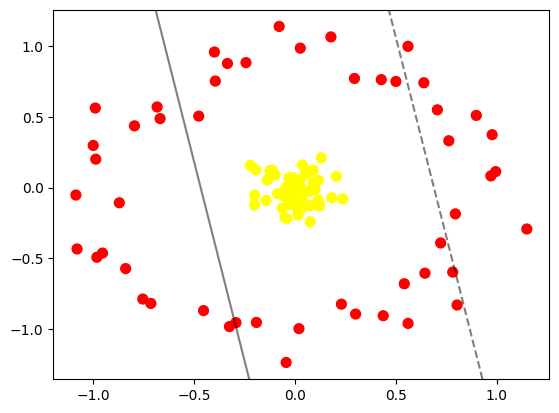

In [40]:
# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

Karena proyeksi radial tidak cukup menggunakan model 2D, maka plot visualisasi diubah menjadi model 3D.

In [42]:
r = np.exp(-(X**2).sum(1))

from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
	    ax = plt.subplot(projection='3d')
	    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
	    ax.view_init(elev=elev, azim=azim)
	    ax.set_xlabel('x')
	    ax.set_ylabel('y')
	    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
	         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[ 5.41497304e-01, -6.81404091e-01],
       [-4.10264252e-02, -2.19718804e-01],
       [ 7.94809436e-01, -1.86515308e-01],
       [ 4.36877039e-01, -9.07629484e-01],
       [ 3.18687352e-02, -7.87633009e-02],
       [ 8.98474464e-01,  5.10812185e-01],
       [-7.90212768e-02,  1.14044758e+00],
       [ 2.29713446e-01, -8.25704155e-01],
       [-9.46174625e-03, -8.92347941e-02],
       [ 5.47322731e-02,  1.15319459e-01],
       [ 5.59906581e-01,  9.99927179e-01],
       [-1.11664449e-01,  1.22546266e-01],
       [ 9.94773448e-01,  1.12849264e-01],
       [-6.84293756e-01,  5.70679643e-01],
       [-8.40160182e-01, -5.73832135e-01],
       [ 9.77268927e-01,  3.74099208e-01],
       [ 6.26234824e-02,  1.07482932e-01],
       [-9.98477051e-03, -2.82245499e-02],
       [-4.72132504e-02, -1.63718050e-03],
       [-3.14818234e-02,  6.85665399e-02],
       [ 9.70615779e-01,  8.23090020e-02],
       [ 1.04068668e-02,  5.56922452e-02],
       [-4.25731321e-02, -5.65021177e-02],
       [-2.20630575e-02, -1.20303263e-01],
       [ 2.04579280e-01,  7.89776293e-02],
       [ 2.57213495e-02,  9.87115682e-01],
       [ 5.24237584e-02,  9.42429704e-02],
       [ 7.73338650e-02, -1.26985189e-01],
       [ 1.52790339e-02, -1.94367527e-01],
       [-9.55116710e-01, -4.64194881e-01],
       [-2.43436658e-01,  8.84424242e-01],
       [ 4.27371141e-01,  7.64032904e-01],
       [-9.90894760e-01,  5.62743448e-01],
       [ 1.77582528e-01,  1.06669914e+00],
       [-1.08115624e+00, -4.34777908e-01],
       [ 4.28711430e-02, -1.37283315e-01],
       [ 5.60141565e-01, -9.62113944e-01],
       [ 3.66480417e-02,  1.59843783e-01],
       [-7.55393531e-01, -7.89554621e-01],
       [-2.00612274e-01, -5.49205692e-02],
       [-3.98929676e-02, -7.10071806e-02],
       [-4.00255248e-01,  9.59613600e-01],
       [ 8.03168658e-01, -8.31916984e-01],
       [-6.14255056e-02, -5.43627586e-02],
       [-8.73993713e-02, -4.33561881e-02],
       [ 3.00182779e-01, -8.95861942e-01],
       [-1.43774166e-01, -9.21591561e-02],
       [-5.00803272e-02, -2.12093497e-01],
       [-1.37260394e-01,  5.36846003e-02],
       [-1.93973934e-01,  1.25605273e-01],
       [-1.26817528e-02,  7.04382005e-02],
       [ 3.52074496e-02, -1.14322875e-01],
       [ 5.00010142e-01,  7.51239132e-01],
       [ 1.20567021e-01, -1.29078021e-01],
       [-3.95649991e-01,  7.53878798e-01],
       [-2.21893056e-01,  1.57326965e-01],
       [ 1.15558102e-01,  5.10847631e-02],
       [ 2.94273103e-01,  7.72141748e-01],
       [ 7.21816794e-01, -3.92429274e-01],
       [-1.91843950e-01, -9.55232043e-01],
       [-4.44067148e-02, -1.23879716e+00],
       [ 1.41664880e-02, -1.59643928e-01],
       [-8.71571185e-01, -1.08015195e-01],
       [-2.00972676e-01, -1.22134529e-01],
       [-5.03559035e-02, -6.53416988e-02],
       [-9.88421344e-01,  2.00900047e-01],
       [-9.83072579e-01, -4.93675861e-01],
       [ 6.43868812e-01, -6.06712284e-01],
       [ 1.81401972e-01, -7.19200456e-02],
       [ 7.62278378e-01,  3.31277737e-01],
       [ 3.51440229e-02, -9.70588653e-03],
       [-7.96574860e-01,  4.36937171e-01],
       [ 8.94324712e-02,  1.23121838e-01],
       [-1.24663752e-01,  1.19764035e-01],
       [ 1.14901637e+00, -2.93705459e-01],
       [-6.39411765e-02, -1.44398016e-01],
       [ 7.05546078e-01,  5.50348772e-01],
       [-9.92688026e-02,  9.06388409e-02],
       [ 1.14355768e-01, -8.79588120e-02],
       [ 1.29465669e-01,  2.10298300e-01],
       [-3.35480920e-01,  8.78432564e-01],
       [-1.08700632e+00, -5.31414845e-02],
       [ 9.91571356e-02, -1.06348122e-02],
       [ 1.92359061e-02, -9.99307958e-01],
       [ 6.38501535e-01,  7.41894812e-01],
       [ 2.33288127e-02,  4.61669187e-02],
       [ 1.04868486e-01, -1.18102379e-01],
       [ 6.96765358e-02, -2.92102507e-02],
       [-6.69460173e-01,  4.88188416e-01],
       [-1.00109682e+00,  2.97986308e-01],
       [ 9.01182681e-02,  3.80743944e-02],
       [-3.25384743e-01, -9.84448745e-01

Langkah 2 - Fitting Model

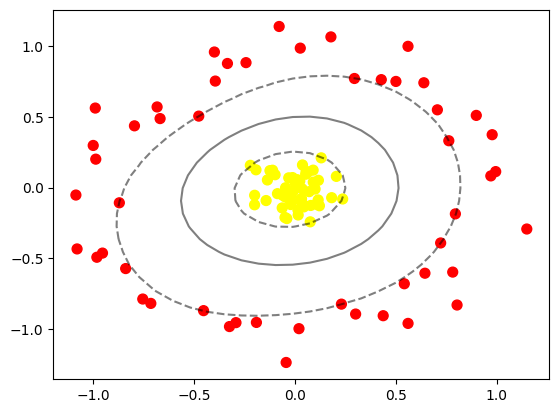

In [43]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
	            s=300, lw=1, facecolors='none')